In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
train_size = int(size -valid_size)

trainset, validset = random_split(images, (train_size, valid_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

40000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.30493370344638826,train_accu=0.8982
Epoch=0,valid_loss=0.38986050221920016,valid_accu=0.8657
0
Epoch=1,train_loss=0.2603810270279646,train_accu=0.907925
Epoch=1,valid_loss=0.38577436730861664,valid_accu=0.8646
Epoch=2,train_loss=0.19879951452165842,train_accu=0.936175
Epoch=2,valid_loss=0.3533139985799789,valid_accu=0.8783
0
Epoch=3,train_loss=0.12170046088658273,train_accu=0.961025
Epoch=3,valid_loss=0.29565548111200335,valid_accu=0.9
0
Epoch=4,train_loss=0.09855498248301446,train_accu=0.968675
Epoch=4,valid_loss=0.30344227102696897,valid_accu=0.9029
0
Epoch=5,train_loss=0.13234292222280056,train_accu=0.95575
Epoch=5,valid_loss=0.39698215069770815,valid_accu=0.8811
Epoch=6,train_loss=0.06084488304285333,train_accu=0.982475
Epoch=6,valid_loss=0.28940404070913794,valid_accu=0.9082
0
Epoch=7,train_loss=0.06270416871532798,train_accu=0.980325
Epoch=7,valid_loss=0.30285373017191886,valid_accu=0.904
Epoch=8,train_loss=0.050707923225243576,train_accu=0.98405
Epoch=8,vali

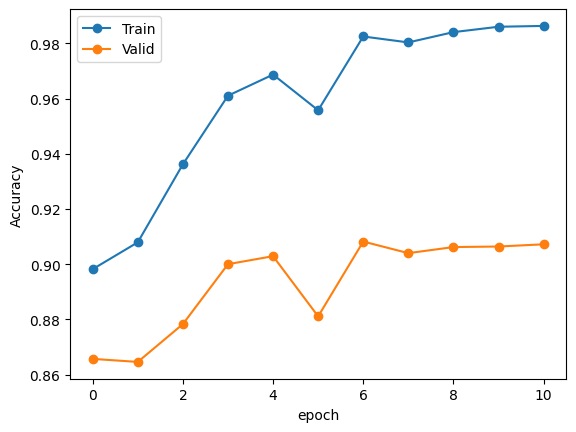

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.06220193367861211, 0.9819)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.2933768690347672, 0.9081)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=2*p*r/(p+r)
each_accu

airplane      0.984770
automobile    0.988116
bird          0.981800
cat           0.959456
deer          0.983586
dog           0.972170
frog          0.984001
horse         0.986082
ship          0.989899
truck         0.988297
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(4).index.map(trainset.dataset.classess)]
targetF

[3, 5, 2, 4]

In [17]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('TandF')
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(710, 39290)

In [18]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(905, 9095)

In [19]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [20]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [63]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,model_0=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    # elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
    #     model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    torch.cuda.empty_cache() 
    return model

Epoch=0,train_loss=0.0121058567334665,train_accu=0.996125
Epoch=0,valid_loss=0.49600191416144374,valid_accu=0.9063
0
Epoch=1,train_loss=0.007021590649793507,train_accu=0.997325
Epoch=1,valid_loss=0.6647913637293502,valid_accu=0.9048
Epoch=2,train_loss=0.005150711139366831,train_accu=0.998325
Epoch=2,valid_loss=0.8059689017918892,valid_accu=0.9052
Epoch=3,train_loss=0.0030006916750564415,train_accu=0.998875
Epoch=3,valid_loss=0.817996050635539,valid_accu=0.907
0
Epoch=4,train_loss=0.002933717164290647,train_accu=0.9989
Epoch=4,valid_loss=1.0125598751333542,valid_accu=0.9062
Epoch=5,train_loss=0.0020596749274046713,train_accu=0.999175
Epoch=5,valid_loss=1.083776117209159,valid_accu=0.9073
0
Epoch=6,train_loss=0.0008157845140580321,train_accu=0.999725
Epoch=6,valid_loss=1.5788785555104548,valid_accu=0.9096
0
Epoch=7,train_loss=0.0020667533253870486,train_accu=0.9993
Epoch=7,valid_loss=1.2592730690572906,valid_accu=0.9073
Epoch=8,train_loss=9.893179242826591e-05,train_accu=1.0
Epoch=8,vali

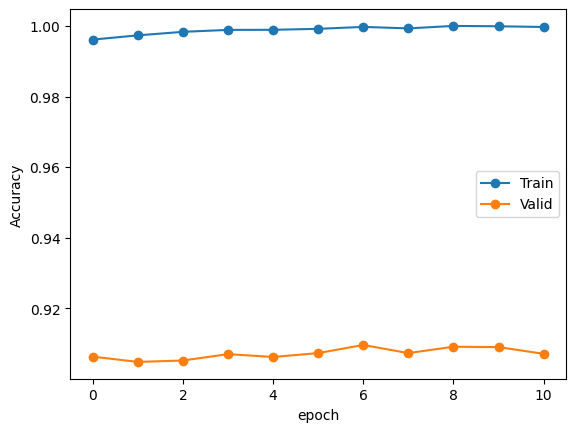

In [64]:
from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,model_0=model_0)

In [23]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.023082168680106624,train_accu=0.9932552812420463
Epoch=0,valid_loss=0.07377911654227771,valid_accu=0.9725123694337549
0
Epoch=1,train_loss=0.01745994552786169,train_accu=0.9946042249936371
Epoch=1,valid_loss=0.074597817324788,valid_accu=0.9746014293567894
0
Epoch=2,train_loss=0.013189391618114584,train_accu=0.9962331382031051
Epoch=2,valid_loss=0.0807123179833695,valid_accu=0.9727322704782848
Epoch=3,train_loss=0.009545367774358856,train_accu=0.9973784678035124
Epoch=3,valid_loss=0.07396990353894807,valid_accu=0.9737218251786696
Epoch=4,train_loss=0.011770607462308187,train_accu=0.9965640111987784
Epoch=4,valid_loss=0.0848176180245278,valid_accu=0.9730621220450797
Epoch=5,train_loss=0.005574174260183468,train_accu=0.9984983456350216
Epoch=5,valid_loss=0.09293206683976997,valid_accu=0.9739417262231995
4 Early stopping!


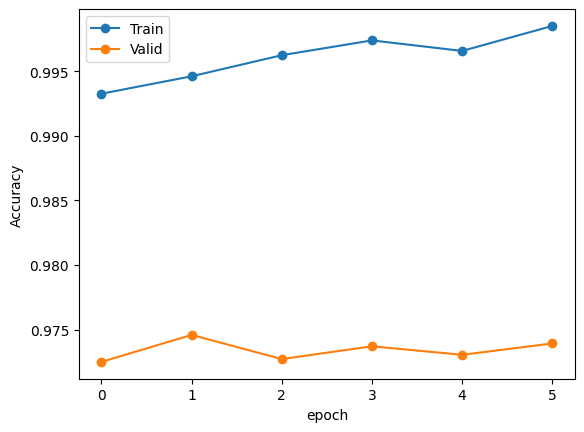

In [24]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.9885897260316661,train_accu=0.6957746478873239
Epoch=0,valid_loss=1.6192245941794379,valid_accu=0.3856353591160221
0
Epoch=1,train_loss=0.5981299569909002,train_accu=0.8366197183098592
Epoch=1,valid_loss=1.5219475229800736,valid_accu=0.4143646408839779
0
Epoch=2,train_loss=0.4074486018906177,train_accu=0.8929577464788733
Epoch=2,valid_loss=1.5901046779274282,valid_accu=0.42099447513812155
0
Epoch=3,train_loss=0.2763219617621999,train_accu=0.9366197183098591
Epoch=3,valid_loss=1.683324037467577,valid_accu=0.40773480662983425
Epoch=4,train_loss=0.18769113001689106,train_accu=0.9647887323943662
Epoch=4,valid_loss=1.7656347787182634,valid_accu=0.450828729281768
0
Epoch=5,train_loss=0.12254184696456076,train_accu=0.9830985915492958
Epoch=5,valid_loss=1.8091061339193946,valid_accu=0.43867403314917125
Epoch=6,train_loss=0.07883153677406446,train_accu=0.9887323943661972
Epoch=6,valid_loss=1.8574816888208547,valid_accu=0.4408839779005525
Epoch=7,train_loss=0.054970337303591

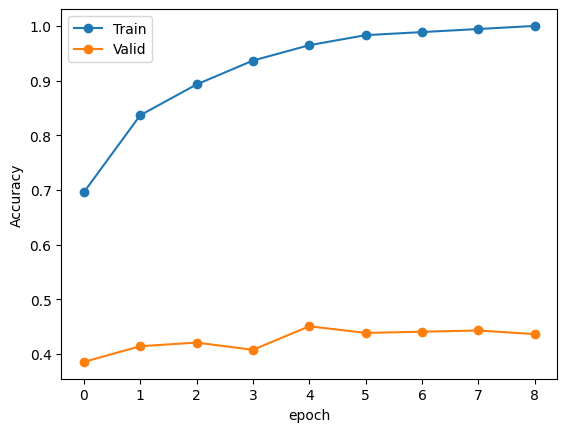

In [25]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [65]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.0004040841033493962, 0.99985)

In [66]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(1.5788785555104548, 0.9096)

In [28]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.01650158659451077, 0.9946551285314329)

In [29]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.19290248479851535, 0.9577464788732394)

In [30]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.07873255084522188, 0.9736118746564046)

In [31]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.747557272700315, 0.44972375690607735)

In [32]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d

(0.0182130940207222, 0.994975)

In [33]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.22803267824202775, 0.9255, 905)

In [67]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.02772497887800273, 0.991225, 463, 39537)

In [68]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.35703782036169435, 0.9158, 41, 9959)

In [69]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [70]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'splitmode={split_mode}')
df

splitmode=TandF


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.062202,0.981900,0.293377,0.908100
1,Model_Decision,0.000404,0.999850,1.578879,0.909600
2,Model_T,0.016502,0.994655,0.078733,0.973612
3,Model_F,0.192902,0.957746,1.747557,0.449724
4,Total_Model,0.027725,0.991225,0.357038,0.915800
5,Total_Model_with_perfect_decision,0.018213,0.994975,0.228033,0.925500


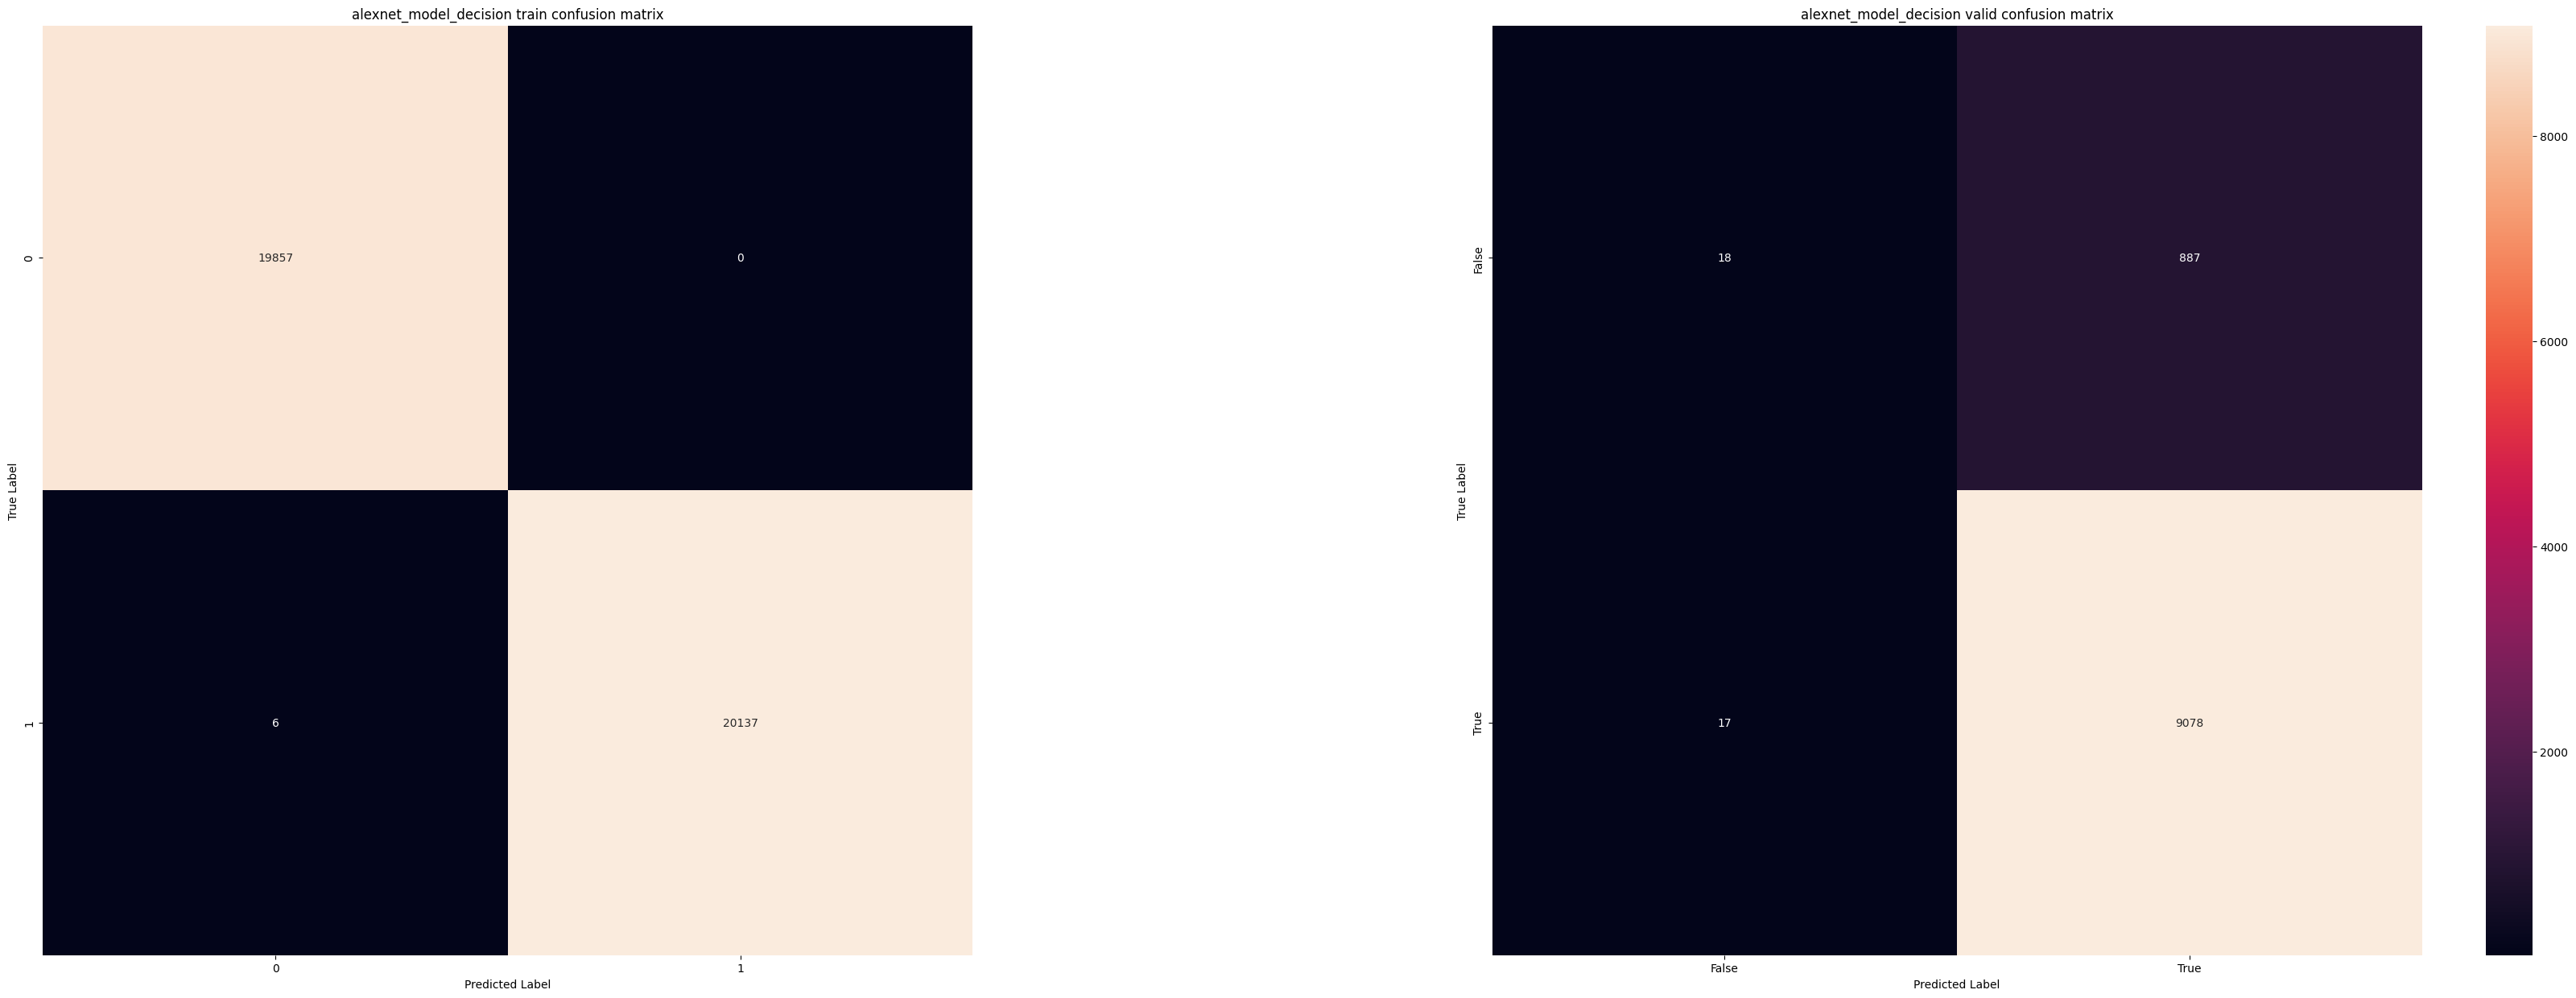

In [71]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

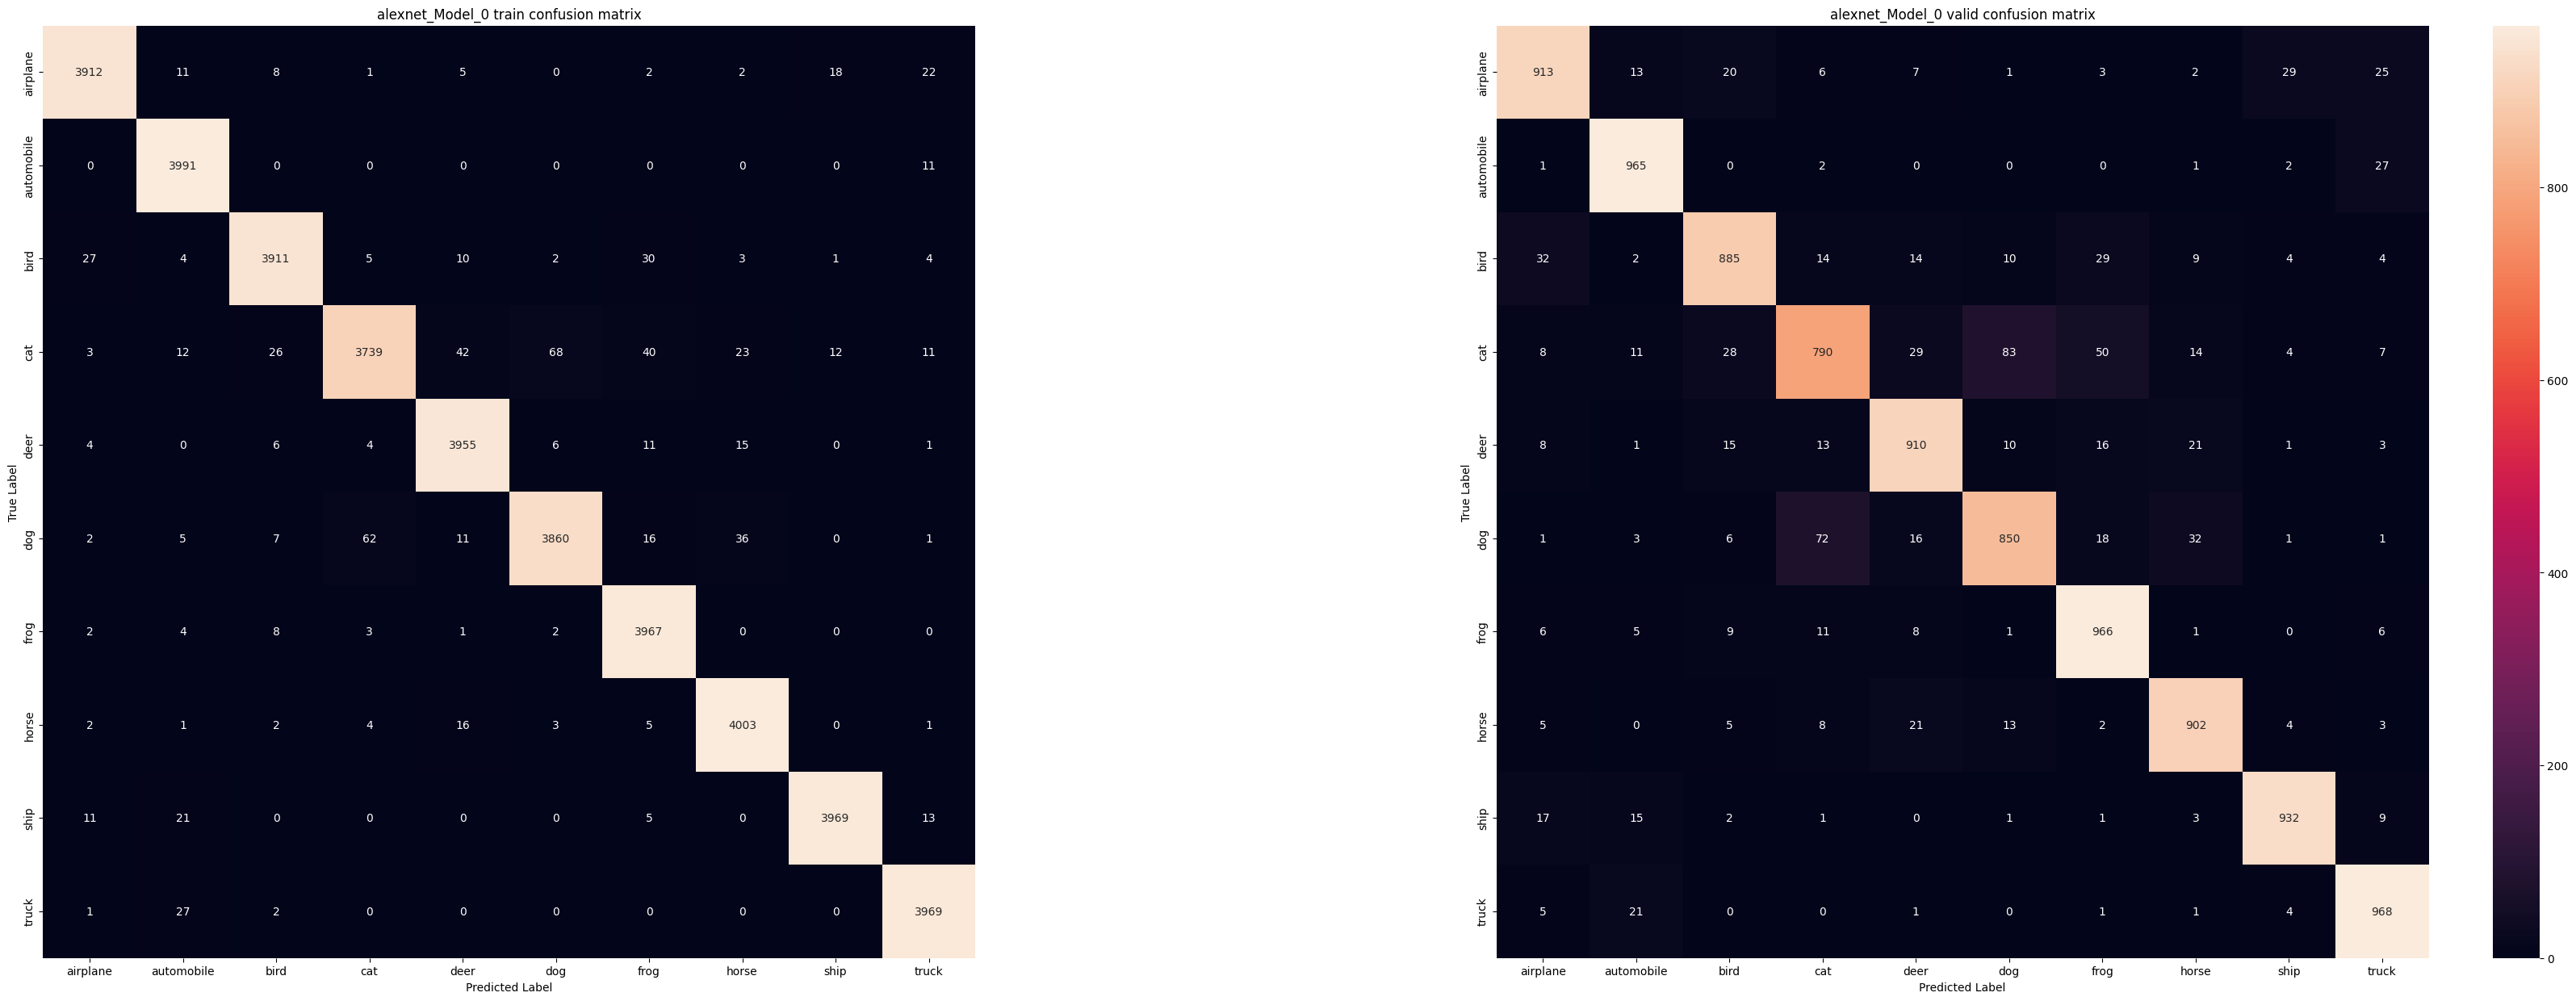

In [39]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

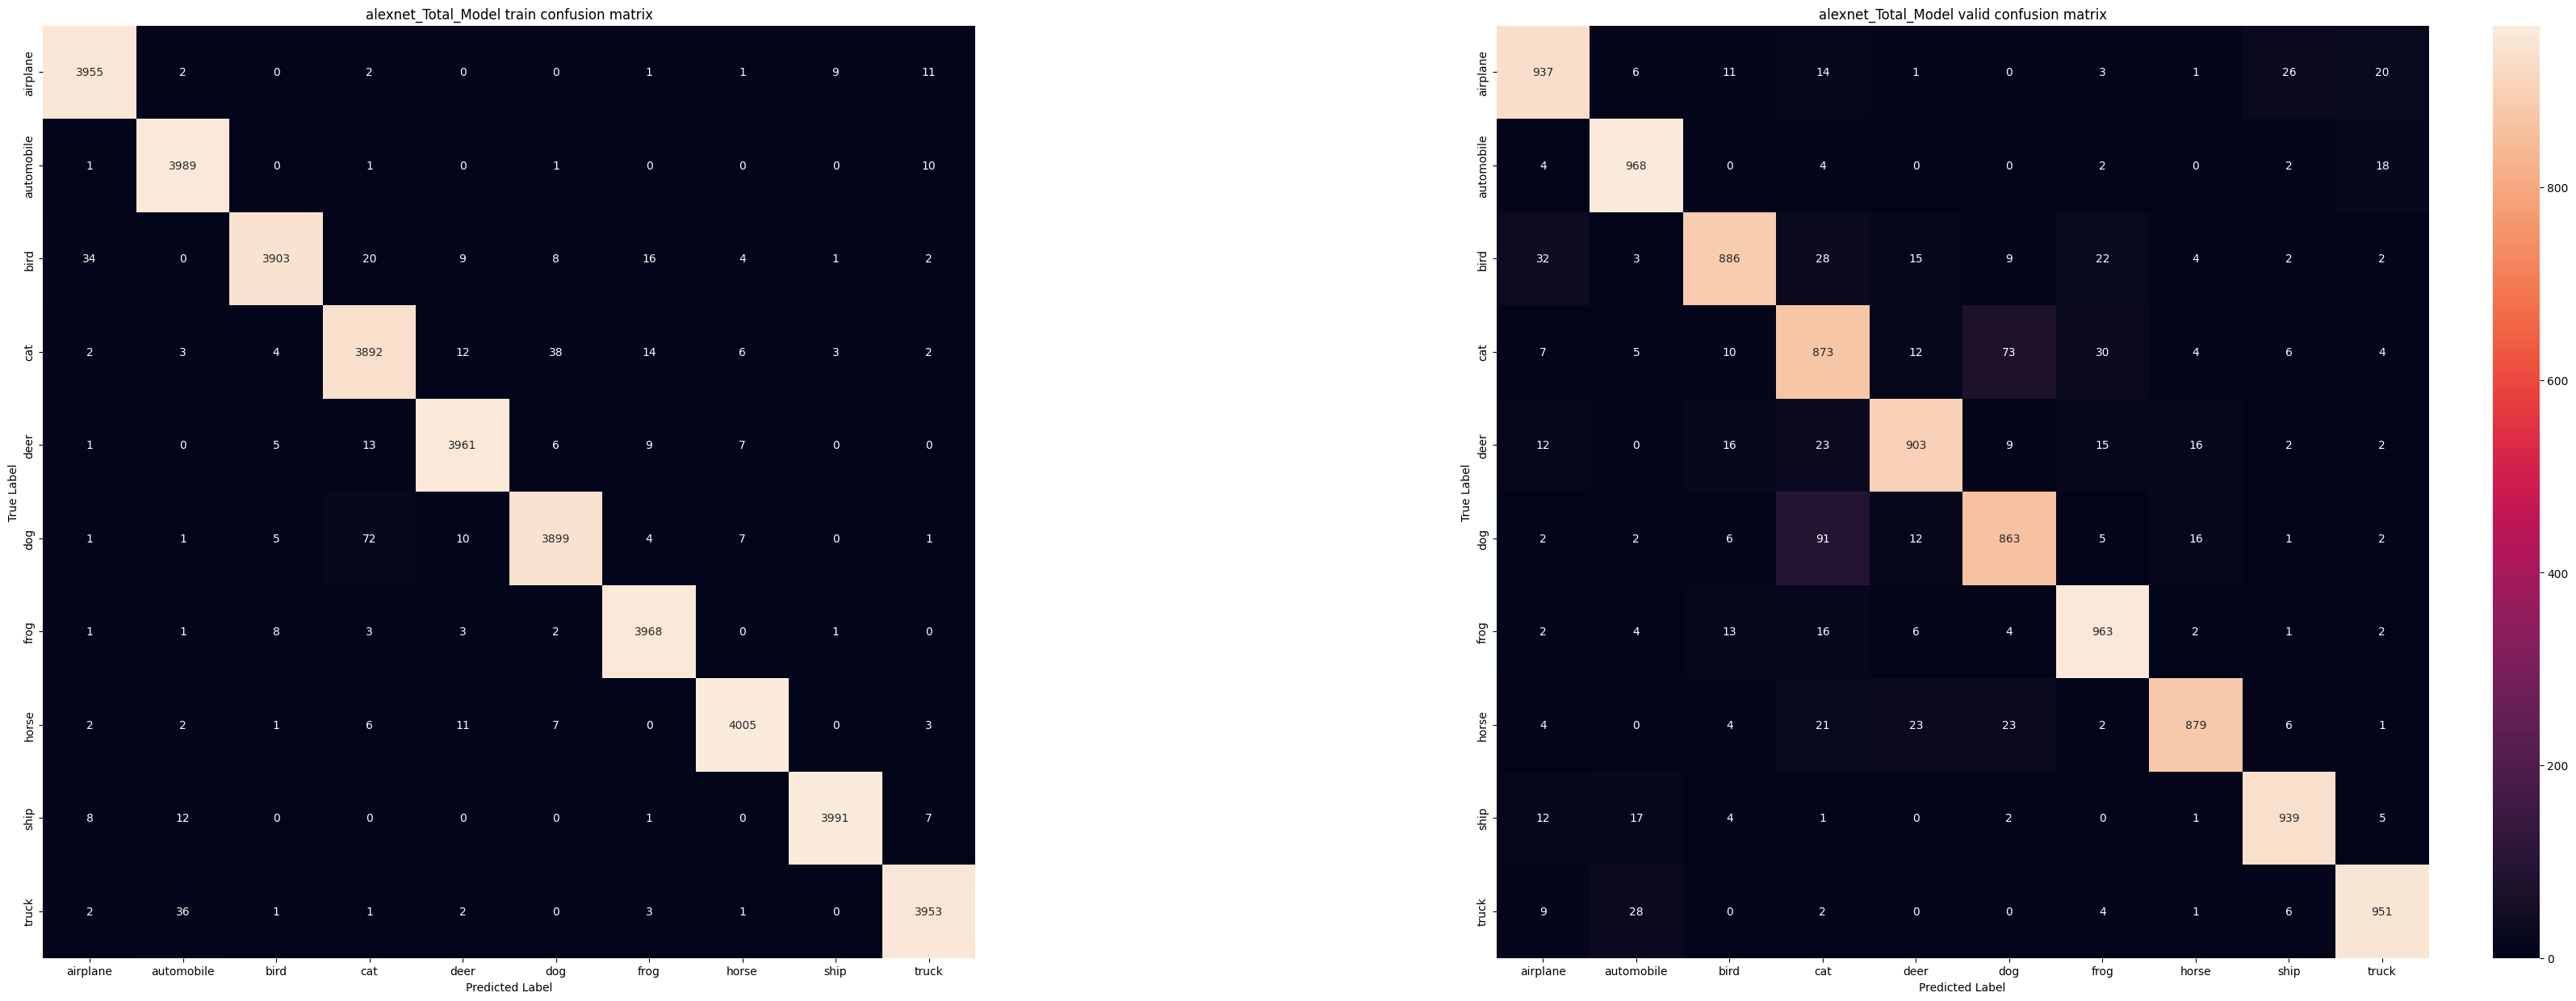

In [40]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

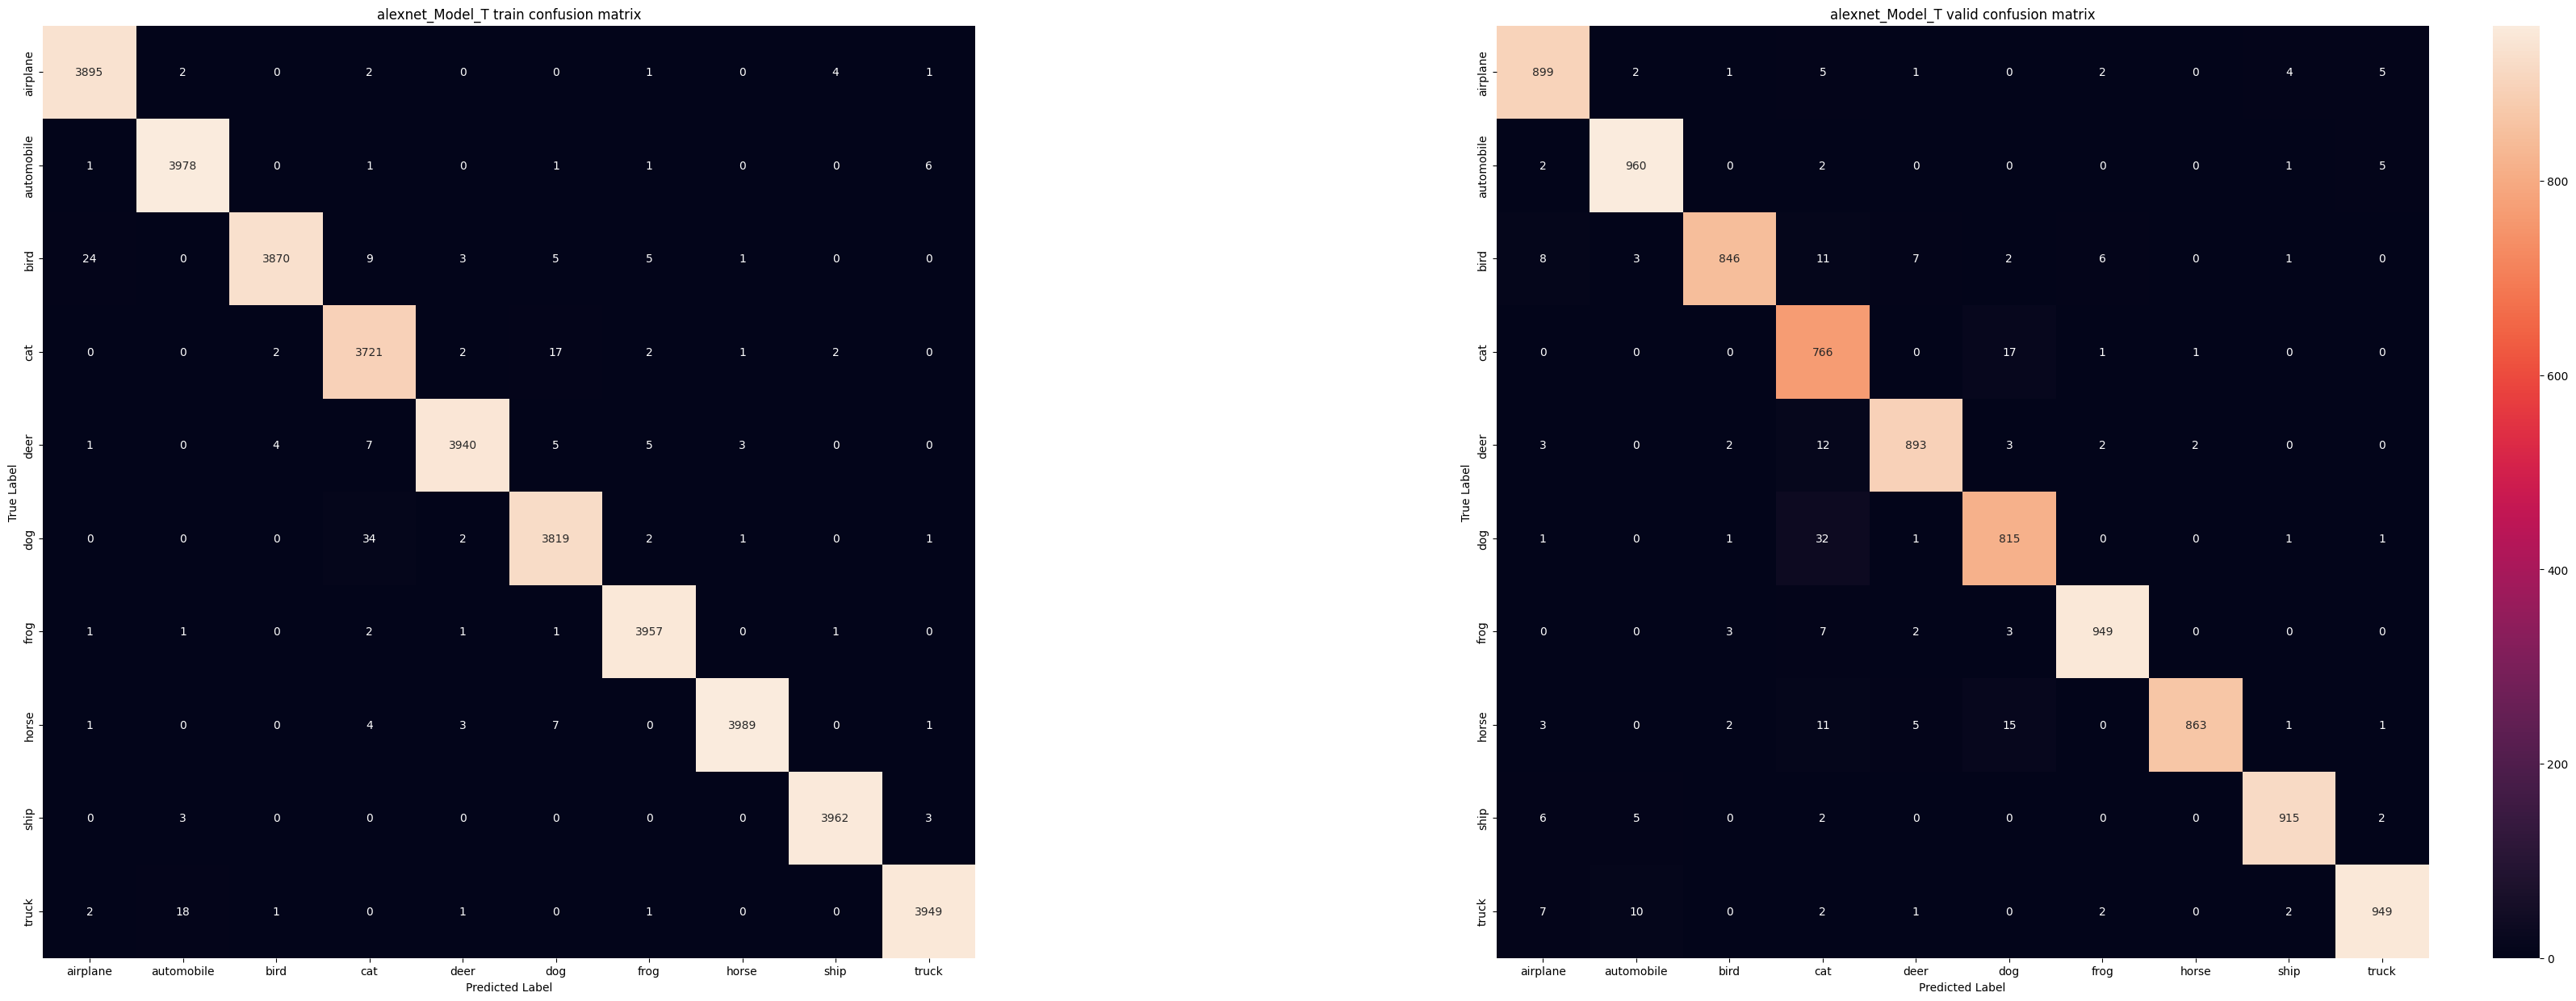

In [41]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

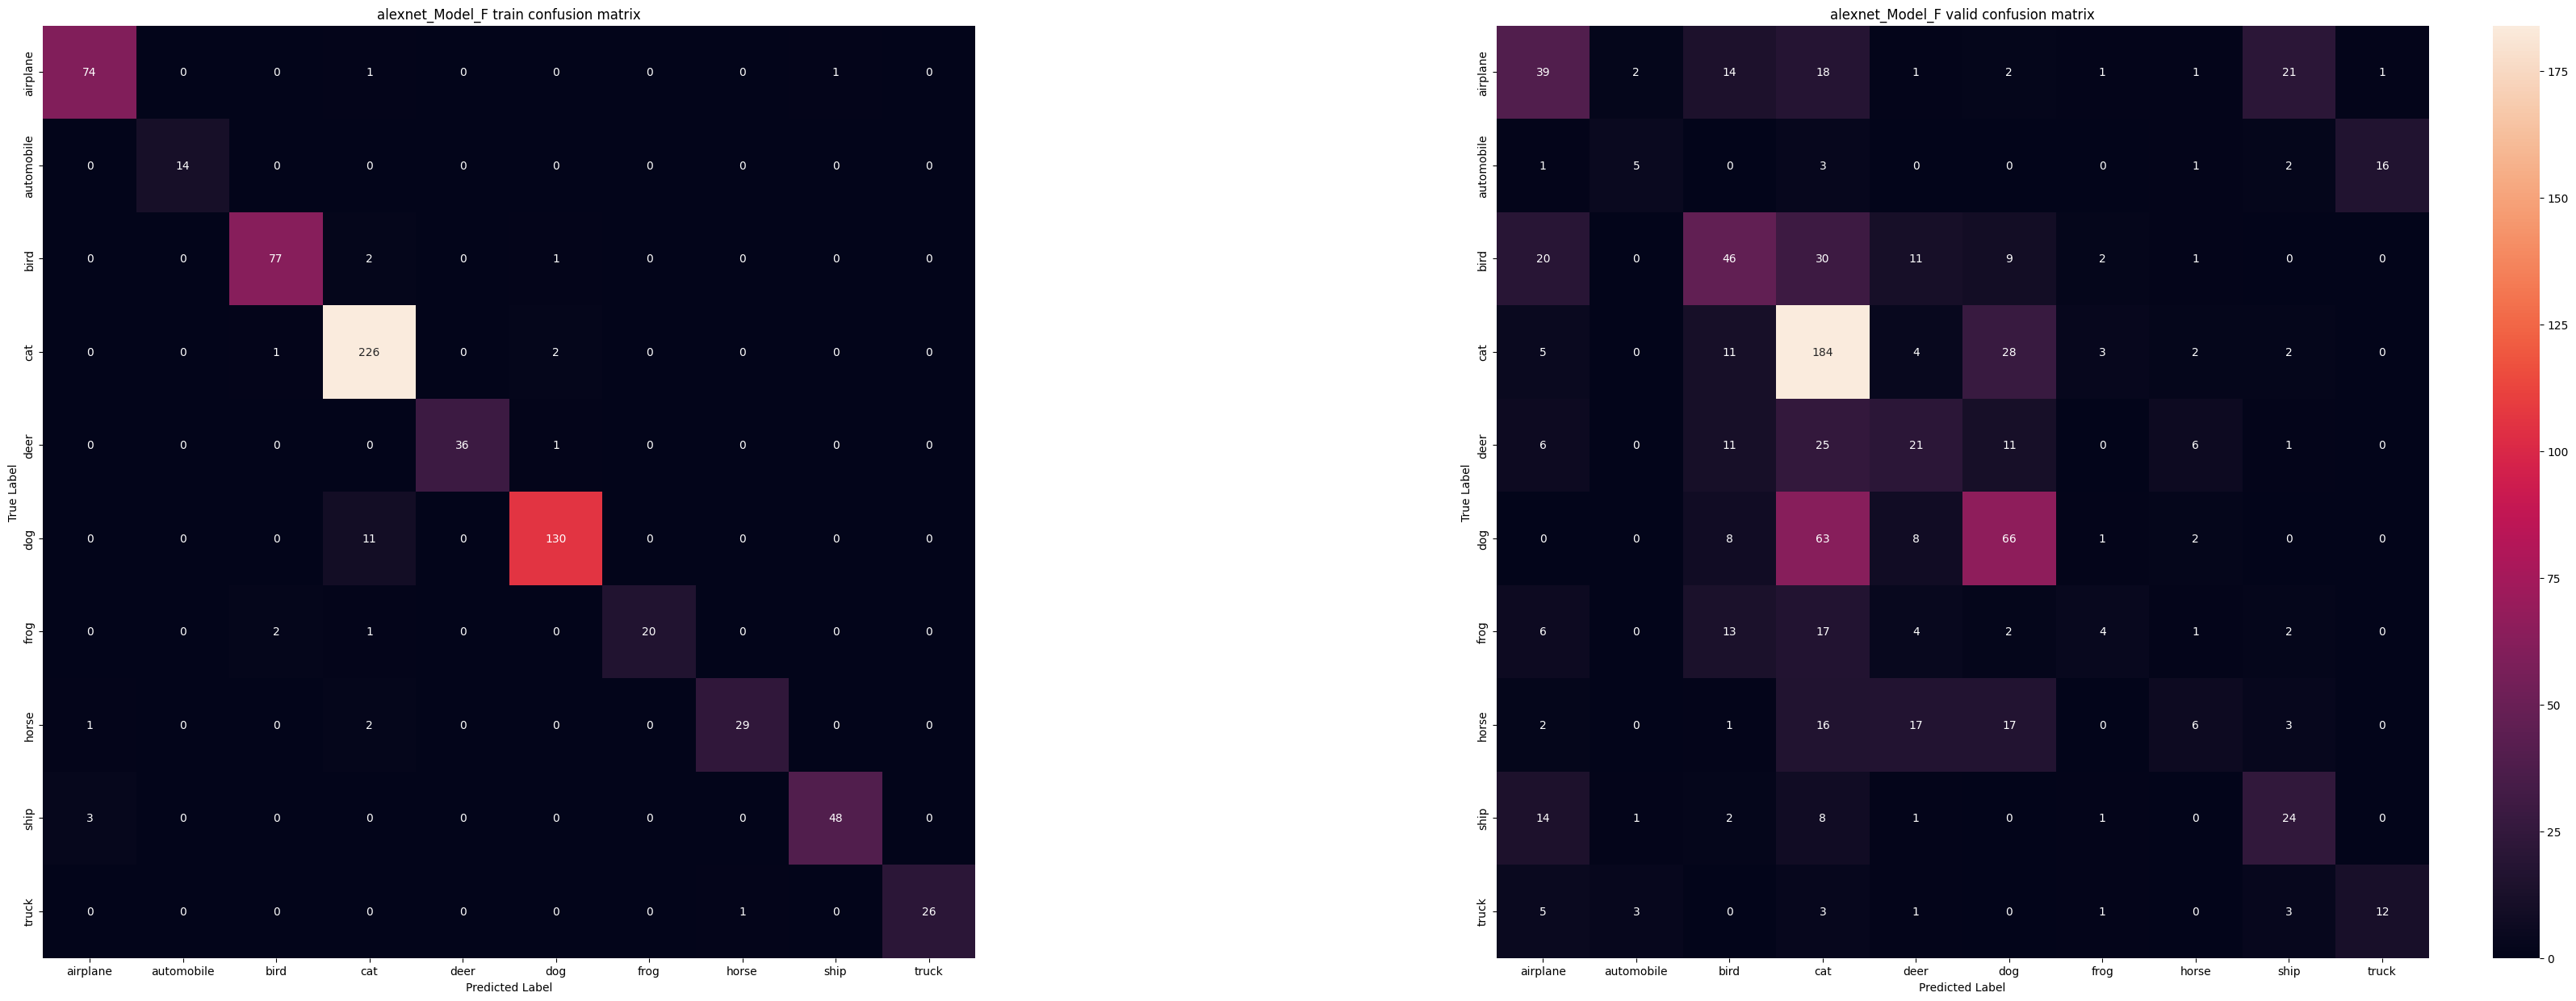

In [42]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [43]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [44]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,14067,1,9,1,1,0.981564,1.000000,1.000000,0.999776,False,True,True,True,True
1,33551,6,6,6,6,0.924769,1.000000,0.999984,0.999370,True,True,True,True,True
2,3204,0,0,0,0,0.999871,1.000000,1.000000,0.998958,True,True,True,True,True
3,7678,8,8,8,8,0.989579,0.999997,0.999275,0.980645,True,True,True,True,True
4,30550,8,8,8,8,0.999999,1.000000,1.000000,0.999986,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39789,3,3,3,3,0.991709,1.000000,0.999233,0.989954,True,True,True,True,True
39996,15408,5,5,5,5,0.673449,0.999810,0.998385,0.990331,True,True,True,True,True
39997,34432,6,6,6,6,0.998371,1.000000,1.000000,0.999983,True,True,True,True,True
39998,9706,6,6,6,6,0.636404,0.997957,0.982390,0.973284,True,True,True,True,True


In [45]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
41,29247,3,3,3,3,0.969142,0.988361,0.516057,0.879591,True,True,True,True,False
75,14937,4,4,4,2,0.833599,0.730877,0.451319,0.935985,True,True,False,True,False
80,8507,3,3,3,3,0.996443,0.997102,0.947379,0.980910,True,True,True,True,False
87,35236,8,8,1,1,0.509368,0.990474,0.891508,0.865488,True,False,False,True,False
92,19551,2,2,6,6,0.946446,0.989243,0.977082,0.983431,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39484,35334,5,5,3,3,0.871229,0.722117,0.627027,0.890713,True,False,False,True,False
39537,21892,0,0,0,2,0.856122,0.734356,0.896782,0.886563,True,True,False,True,False
39660,22919,3,3,3,6,0.989781,0.684240,0.564264,0.969910,True,True,False,True,False
39742,47713,8,8,1,1,0.971549,0.706852,0.843452,0.913227,True,False,False,True,False


In [46]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

3    229
5    141
2     80
0     76
8     51
4     37
7     32
9     27
6     23
1     14
Name: Target, dtype: int64

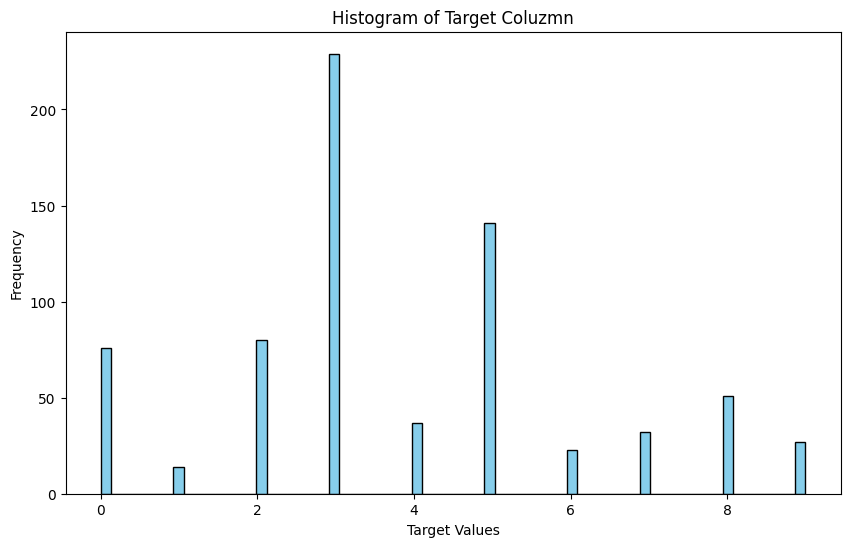

In [47]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [48]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,46205,3,3,3,3,0.999678,1.000000,0.999997,0.999837,True,True,True,True,True
1,34096,8,8,8,8,0.999998,1.000000,1.000000,0.999997,True,True,True,True,True
2,34498,3,3,3,3,0.928461,0.995630,0.635542,0.933090,True,True,True,True,True
3,474,2,2,2,2,0.984660,1.000000,0.999998,0.997424,True,True,True,True,True
4,13883,8,8,8,8,0.888365,0.997667,0.999380,0.982715,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,34192,5,5,5,5,0.935670,1.000000,1.000000,0.999996,True,True,True,True,True
9996,35075,2,2,2,2,0.999742,1.000000,0.999998,0.998030,True,True,True,True,True
9997,20345,3,3,3,3,0.974532,0.999152,0.913123,0.819695,True,True,True,True,True
9998,42307,1,8,1,1,0.921987,0.972183,0.564067,0.890830,False,True,True,True,True


In [49]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
13,12506,2,0,0,0,0.865436,0.966946,0.939720,0.989676,False,False,False,True,False
36,28976,5,3,3,3,0.899529,0.959195,0.818468,0.874968,False,False,False,True,False
44,5922,2,2,6,6,0.703264,0.919497,0.948983,0.976732,True,False,False,True,False
48,19293,5,5,5,3,0.556627,0.586217,0.439595,0.851771,True,True,False,True,False
64,28323,8,3,8,8,0.631179,0.759836,0.975742,0.903019,False,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9960,19634,0,0,8,8,0.605233,0.846444,0.851217,0.967381,True,False,False,True,False
9965,27163,2,5,2,2,0.515418,0.598897,0.615449,0.881124,False,True,True,True,False
9977,28773,3,3,3,4,0.431173,0.706516,0.653110,0.945249,True,True,False,True,False
9989,44748,5,3,5,5,0.627809,0.494244,0.411458,0.883095,False,True,True,True,False


In [50]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

3    239
5    148
2    119
0    100
4     81
7     62
8     51
6     49
1     28
9     28
Name: Target, dtype: int64

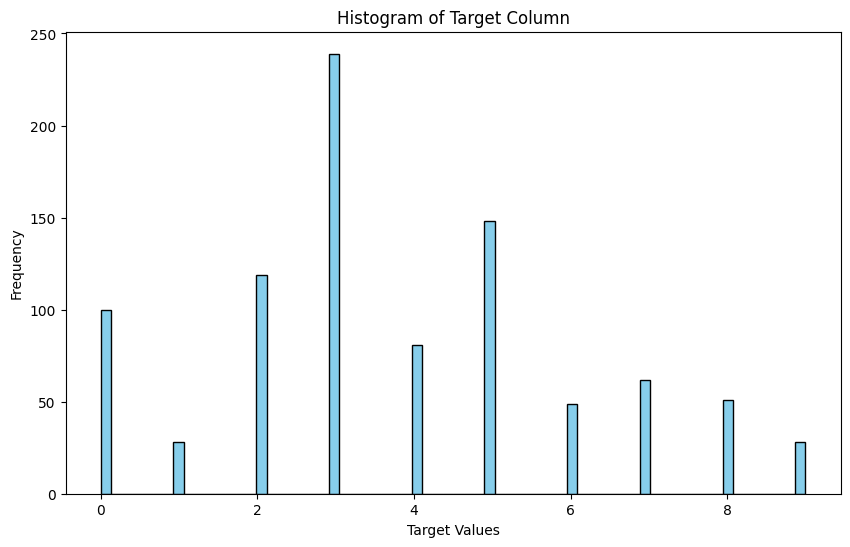

In [51]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()